In [2]:
import re
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import anndata as ad
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro, kstest, norm, wilcoxon, ttest_rel
from adjustText import adjust_text
from collections import defaultdict
from Bio import SeqIO

In [ ]:
# plot appearance default parameters
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=8)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

## 1 - Data

In [3]:
# raw adata from scRNA-seq and enhancer data
adata_sc =  sc.read_h5ad('../data/scRNAseq.h5ad')
adata_enh = ad.read_h5ad('../data/Enhancers_AnnData.h5ad')

In [4]:
adata_sc

AnnData object with n_obs × n_vars = 295141 × 21237
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'Sample', 'Sample_type', 'Age', 'Origin', 'batch', 'S_score', 'G2M_score', 'phase', 'leiden', 'ann_clusters', 'primate_score', 'background_score'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'ann_clusters_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# new cluster annotation
remapping_clusters = {
    'Progenitor': [4],
    'Subdermal': [10],
    'Meningeal': [8],
    'Early Mesenchyme': [9 , 2, 11], 
    'Osteogenic': [1], 
    'Stroma': [0, 5], 
    'Dermal': [3], 
    'Chondrogenic': [6], 
    'Endothelia': [15], 
    'Perivascular': [13], 
    'Immune': [17, 23],
    'Erythrocyte': [18], 
    'Glia': [14], 
    'Epithelia': [21],
    'Neuronal': [12, 22, 20, 16],
    'Myoblast': [7, 19]
}

inverse = {}
for k,v in remapping_clusters.items():
    for x in v:
        inverse.setdefault(x, []).append(k)

In [ ]:
remapping_clusters = dict(sorted(inverse.items()))
remapping_clusters = {str(k): v[0] for k,v in remapping_clusters.items()}

In [ ]:
adata_sc.obs['ann_clusters'] = adata_sc.obs['leiden'].map(remapping_clusters)
adata_sc.obs['ann_clusters']

AAACCCAAGTAAACAC-1-0-0     Chondrogenic
AAACCCACAAGTCATC-1-0-0     Chondrogenic
AAACCCACACTATCGA-1-0-0       Osteogenic
AAACCCAGTACGTTCA-1-0-0     Chondrogenic
AAACCCAGTATCAGCT-1-0-0     Chondrogenic
                               ...     
TTTGTCTAGTCATTGA-1-27-1        Myoblast
TTTGTGAAGAATGACG-1-27-1          Dermal
TTTGTGAAGTTATTCC-1-27-1    Perivascular
TTTGTGGCAATAGCCC-1-27-1       Meningeal
TTTGTTGGTCACAAAT-1-27-1          Stroma
Name: ann_clusters, Length: 295141, dtype: object

<Figure size 1200x1200 with 0 Axes>

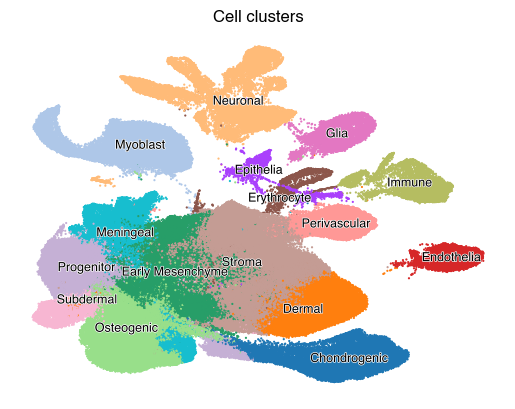

In [ ]:
# UMAP
fig = plt.figure(figsize=(4,4), dpi=300)

fig.patch.set_alpha(0)
fig.set_facecolor("none")

ax = sc.pl.umap(
    adata_sc,
    color="ann_clusters",
    legend_loc="on data",
    frameon=False,
    show=False, size=10
)


ax.set_title("Cell clusters", fontsize=12, fontweight="bold")

for text in ax.texts:
    text.set_fontsize(9)
    text.set_fontweight("bold")
    text.set_path_effects([pe.withStroke(linewidth=1, foreground="white")])

plt.savefig(f"../plots/UMAP_general.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

<Axes: ylabel='total_counts'>

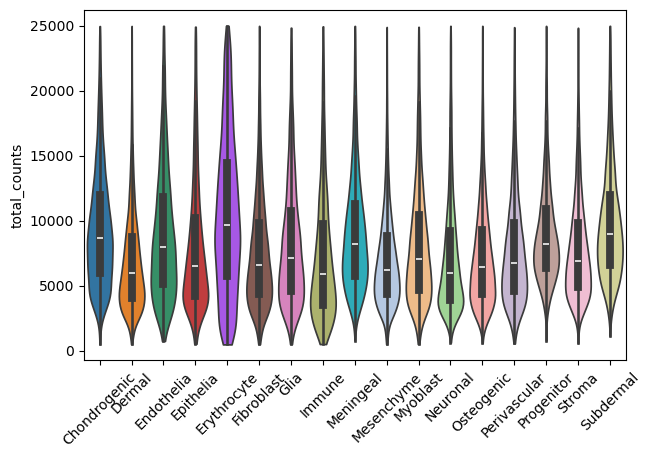

In [ ]:
sc.pl.violin(
    adata_sc,
    keys="total_counts",
    groupby="ann_clusters",
    stripplot=False,
    inner="box",
    rotation=45,
    show=False,
    )

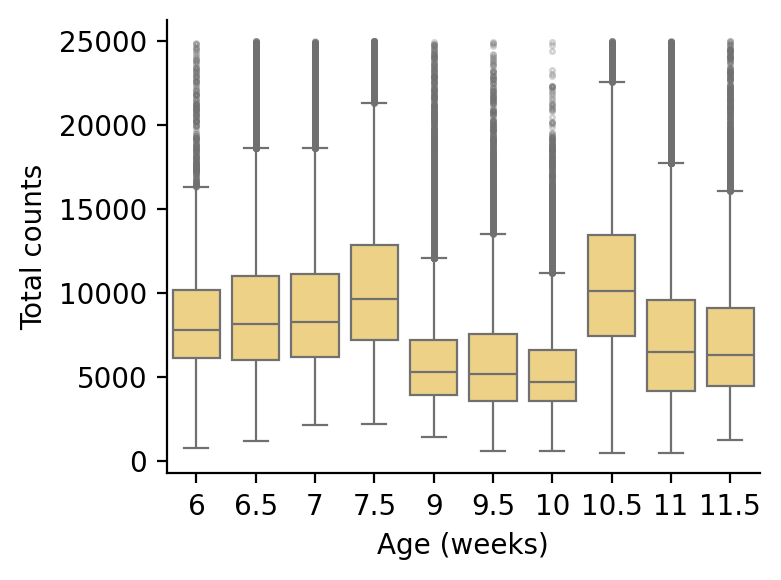

In [7]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

sns.boxplot(data=adata_sc.obs, x='Age', y='total_counts',
            color='#FED976',
            linewidth=0.8,
            flierprops=dict(marker='o', markersize=1.5, 
                            alpha=0.3, linewidth=0), ax=ax)

ax.set_xlabel('Age (weeks)')
ax.set_ylabel('Total counts')
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

## 2 - Primates genes expression - analysis

### 2.1 Gene expression scoring against all other genes

In [8]:
adata_enh.var["category"].value_counts()

category
other               8730
conservative        2929
primate_specific      84
human_unique           5
Name: count, dtype: int64

In [9]:
# getting gene names associated with primate specific enhancers
primate_genes = adata_enh.var.loc[adata_enh.var["category"] == "primate_specific", "gene"]

target_genes = set()
for genes in primate_genes.dropna():
    for g in str(genes).split(","):
        g = g.strip()
        if g: #not in avoid_genes:
            target_genes.add(g)

target_genes = sorted([gene for gene in target_genes if gene in adata_sc.var_names])

In [10]:
# getting the rest of the genes
rest_genes = adata_enh.var.loc[:, "gene"]

background_genes = set()
for genes in rest_genes.dropna():
    for g in str(genes).split(","):
        g = g.strip()
        if g not in target_genes:
            background_genes.add(g)

background_genes = sorted([gene for gene in background_genes if gene in adata_sc.var_names])

In [12]:
print(f"Number of genes associated with primate-specific enhancers: {len(target_genes)}")
print(f"Number of genes not associated with primate-specific enhancers: {len(background_genes)}")
print(f"Total number of genes in the analysis: {len(target_genes) + len(background_genes)}")

Number of genes associated with primate-specific enhancers: 100
Number of genes not associated with primate-specific enhancers: 3735
Total number of genes in the analysis: 3835


In [ ]:
#scoring primate gene sample
sc.tl.score_genes(
    adata_sc,
    gene_list=target_genes,
    score_name="primate_score",
    ctrl_size=len(target_genes)
)

In [ ]:
#scoring the rest gene sample
sc.tl.score_genes(
    adata_sc,
    gene_list=background_genes,
    score_name="background_score",
    ctrl_size=len(background_genes)
)

In [ ]:
#saving the object (cluster names and different scores added)
filename = '../data/scRNAseq.h5ad'
adata_sc.write_h5ad(filename)

### 2.2 Gene score comparison

In [14]:
# functions
def cohen_d(x, y):
    d = x - y
    return d.mean() / d.std()

def ttest_per_cluster(df: pd.DataFrame,
                         cluster_col: str = "cluster",
                         x_col: str = "set1",
                         y_col: str = "set2",
                         alternative: str = "two-sided",
                         min_n: int = 20,
                        )-> pd.DataFrame:
    results = []
    for cl, g in df.groupby(cluster_col, sort=False):
        if len(g) < min_n:
            continue
        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()
        d = x - y

        # normality check on differences
        ks_stat, ks_pval = kstest(d, 'norm', args=(d.mean(), d.std()))

        # t-test for normally distributed
        stat_t, pval_t = ttest_rel(x, y, alternative=alternative)
        
        # Wilcoxon test for not-normally distributed
        stat_w, pval_w = wilcoxon(x, y, alternative=alternative, zero_method="wilcox")
                
        results.append({
            "cluster": cl,
            "n_cells": len(g),
            "median_diff": np.median(d),
            "ks_stat": ks_stat,
            "ks_pval": ks_pval,
            "t_stat": stat_t,
            "t_pval": pval_t,
            "cohen_d": cohen_d(x, y),
            "w_stat": stat_w,
            "w_pval": pval_w,
        })
        
    res = pd.DataFrame(results)
    mask = res["t_pval"].notna()
    if mask.any():
        _, qvals, _, _ = multipletests(res.loc[mask, "t_pval"], method="bonferroni")
        res.loc[mask, "adj_pval"] = qvals
    else:
        res["adj_pval"] = np.nan
    
    res = res.sort_values(["median_diff"], na_position="last", ascending=False).reset_index(drop=True)
    return res

In [15]:
df = adata_sc.obs[['primate_score', 'background_score', 'ann_clusters']]
df[['primate_score', 'background_score']].describe()

,primate_score,background_score
count,295141.000000,295141.000000
mean,0.251437,0.173776
std,0.084163,0.041755
min,-0.101668,-0.040806
25%,0.196026,0.147715
50%,0.251778,0.174106
75%,0.307667,0.201061
max,0.618372,0.362839


In [16]:
#check the normal distribution
x = df['primate_score'].to_numpy()
y = df['background_score'].to_numpy()

ks_stat_x, ks_pval_x = kstest(x, 'norm', args=(x.mean(), x.std()))
ks_stat_y, ks_pval_y = kstest(y, 'norm', args=(y.mean(), y.std()))

print(f"Primate score  — KS stat: {ks_stat_x:.4f}, p: {ks_pval_x:.2e}")
print(f"Background score — KS stat: {ks_stat_y:.4f}, p: {ks_pval_y:.2e}")

Primate score  — KS stat: 0.0054, p: 6.06e-08
Background score — KS stat: 0.0165, p: 2.09e-70


In [17]:
# global difference between primate set and background set
stat, pval = ttest_rel(x, y, alternative='two-sided')
d = cohen_d(x, y)

print(f"T stat: {stat:.2f}")
print(f"p-value:       {pval:.2e}")
print(f"Cohen's d:     {d:.3f}")
print(f"median primate:    {np.median(x):.4f}")
print(f"median background: {np.median(y):.4f}")
print(f"median diff:       {np.median(x - y):.4f}")

T stat: 566.64
p-value:       0.00e+00
Cohen's d:     1.043
median primate:    0.2518
median background: 0.1741
median diff:       0.0748


In [18]:
# difference per cluster between primate set and background set
ttest_res_res = ttest_per_cluster(df, 
                                   cluster_col="ann_clusters",
                                   x_col="primate_score", 
                                   y_col="background_score",
                                   min_n=20
                                 )
ttest_res_res

/tmp/ipykernel_1260104/2993428743.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cl, g in df.groupby(cluster_col, sort=False):


,cluster,n_cells,median_diff,ks_stat,ks_pval,t_stat,t_pval,cohen_d,w_stat,w_pval,adj_pval
0,Stroma,57192,0.109392,0.018886,3.760142e-18,375.967532,0.000000e+00,1.572123,15789853.0,0.000000e+00,0.000000e+00
1,Myoblast,20689,0.103848,0.018110,2.519901e-06,221.982357,0.000000e+00,1.543331,2304020.0,0.000000e+00,0.000000e+00
2,Chondrogenic,18186,0.095106,0.026919,7.005149e-12,213.440435,0.000000e+00,1.582778,1416281.0,0.000000e+00,0.000000e+00
3,Perivascular,8537,0.093899,0.021435,7.718387e-04,143.336599,0.000000e+00,1.551422,366653.0,0.000000e+00,0.000000e+00
4,Dermal,22589,0.093362,0.040694,6.107626e-33,212.493937,0.000000e+00,1.413864,3378368.0,0.000000e+00,0.000000e+00
5,Early Mesenchyme,47332,0.067415,0.016657,7.740808e-12,222.422429,0.000000e+00,1.022364,77283643.0,0.000000e+00,0.000000e+00
6,Glia,6169,0.064199,0.028264,1.027068e-04,76.646337,0.000000e+00,0.975931,1471199.0,0.000000e+00,0.000000e+00
7,Osteogenic,36809,0.060020,0.027449,1.583845e-24,165.426257,0.000000e+00,0.862250,73461711.0,0.000000e+00,0.000000e+00
8,Subdermal,9400,0.058667,0.014942,2.976811e-02,109.601800,0.000000e+00,1.130516,2246191.0,0.000000e+00,0.000000e+00
9,Progenitor,21059,0.054612,0.022640,8.281311e-10,122.352191,0.000000e+00,0.843147,25305281.0,0.000000e+00,0.000000e+00


In [19]:
# cluster order for visualisation
cluster_order = ttest_res_res['cluster'].to_list()
score_order = ['primate_score', 'background_score']

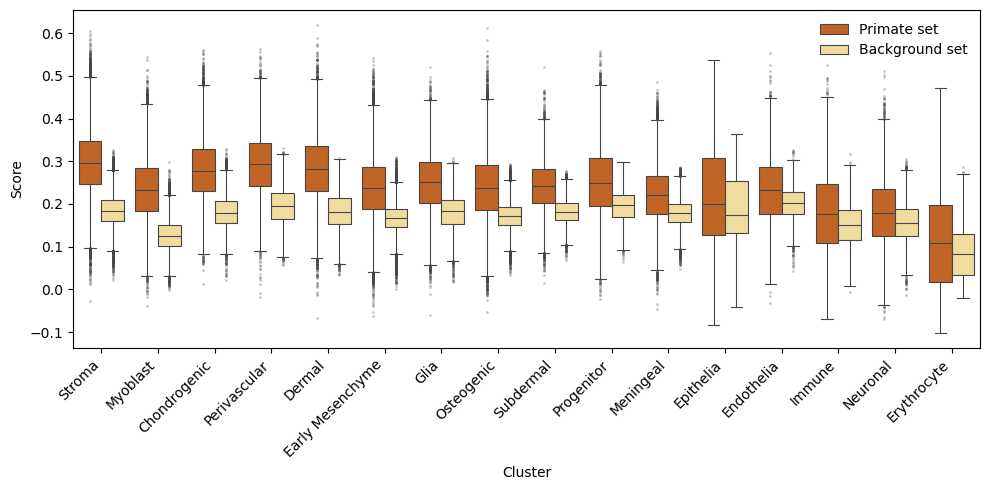

In [22]:
# transformation to the long df
df = adata_sc.obs[["ann_clusters", "primate_score", "background_score"]].copy()

df_long = df.melt(
    id_vars=["ann_clusters"],
    value_vars=["primate_score", "background_score"],
    var_name="score_type",
    value_name="score"
)

# plot
fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(cluster_order)), 5))
palette = sns.color_palette(['#d95f0e', '#FEE391'])

sns.boxplot(
    data=df_long,
    x="ann_clusters",
    y="score",
    hue="score_type",
    order=cluster_order,
    hue_order=score_order,
    dodge=True,          # two violins per cluster
    linewidth=0.8,
    palette=palette,
    flierprops=dict(marker='o', markersize=1, alpha=0.3, linewidth=0),
    ax=ax
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Score")
ax.set_title("")
plt.xticks(rotation=45, ha="right")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Primate set", "Background set"], title="", frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("../plots/2_2_Box_plots.pdf", dpi=300, bbox_inches="tight",  transparent=True)
plt.show()

## 2.3 Per age comparison

In [ ]:
df = adata_sc.obs[["Age", "ann_clusters", "primate_score", "background_score"]].copy()
df["Age"] = df["Age"].astype("category")
df["delta_score"] = df["primate_score"] - df["background_score"]

mat = df.pivot_table(
    index="ann_clusters",
    columns="Age",
    values="delta_score",
    aggfunc="median"
)
mat.shape

/tmp/ipykernel_762943/1713850855.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = df.pivot_table(


(17, 10)

/tmp/ipykernel_2504221/4082748955.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = df.pivot_table(


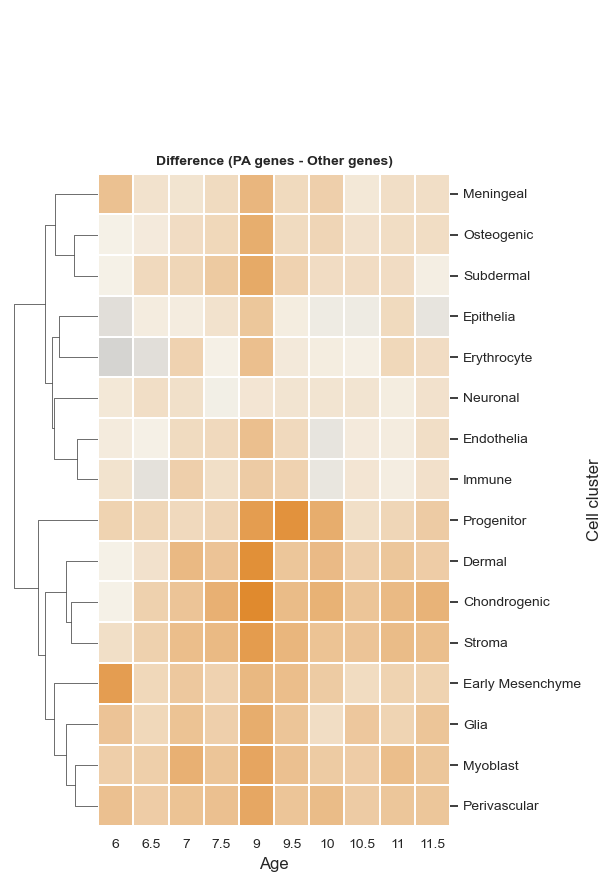

In [ ]:
# coloring
custom_div = mpl.colors.LinearSegmentedColormap.from_list(
    "custom_div",
    ["#707786", "#F5F1E8", "#E08A2E"]
)

sns.set_theme(style="white")

# plot
mat_plot = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
v = np.nanmax(np.abs(mat_plot.to_numpy()))

g = sns.clustermap(
    mat_plot,
    cmap=custom_div,
    center=0,
    vmin=-v,
    vmax=v,
    linewidths=0.3,
    linecolor="#FFFFFF",
    figsize=(6.4, 9),
    col_cluster=False,
    cbar_pos=None,
)

# transparent background
g.patch.set_alpha(0)
g.set_facecolor("none")
g.ax_heatmap.set_facecolor("none")


g.ax_heatmap.set_xlabel("Age")
g.ax_heatmap.set_ylabel("Cell cluster")
g.ax_heatmap.set_title("Difference (PA genes - Other genes)", fontweight="bold")
g.ax_heatmap.tick_params(axis="x", labelsize=10, rotation=0)
g.ax_heatmap.tick_params(axis="y", labelsize=10)

g.savefig("../plots/Matrix_difference.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

/tmp/ipykernel_1271407/4172442854.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


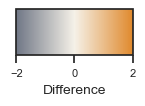

In [ ]:
# legend
fig, ax = plt.subplots(figsize=(1.5, 0.6))
cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=custom_div,
    norm=mpl.colors.Normalize(vmin=-2, vmax=2),
    orientation="horizontal"
)

cb.set_label("Difference", fontsize=10)
cb.ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig("../plots/Matrix_legend.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

/tmp/ipykernel_2504221/4271442272.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_cluster = mean_expr.groupby('cluster')[target_genes].mean()
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


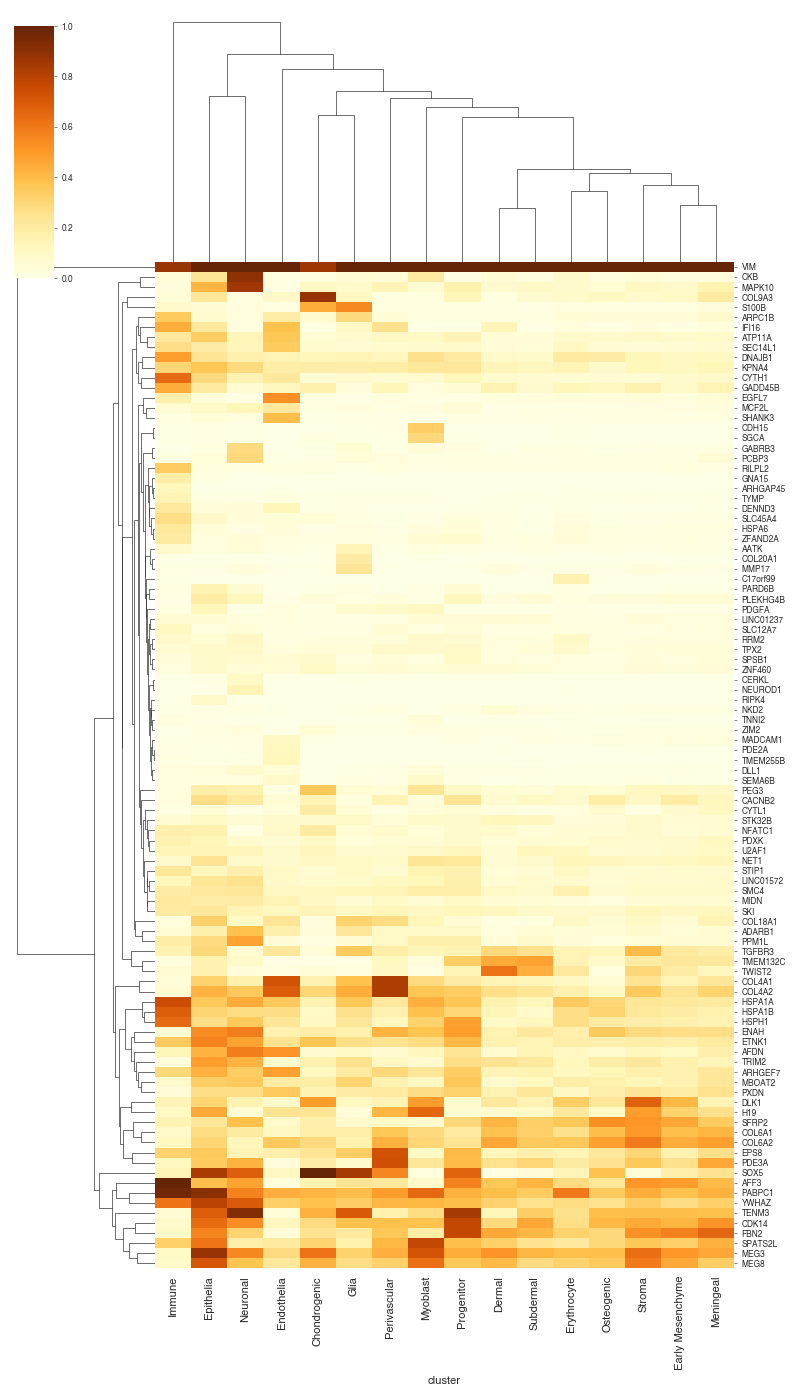

In [ ]:
# Expanded matrix with mean expression of each gene in each cell cluster
# compute mean expression per cluster
mean_expr = pd.DataFrame(
    adata_sc[:, target_genes].X.toarray() if hasattr(adata_sc[:, target_genes].X, 'toarray')
    else np.array(adata_sc[:, target_genes].X),
    columns=target_genes
)
mean_expr['cluster'] = adata_sc.obs['ann_clusters'].values
mean_per_cluster = mean_expr.groupby('cluster')[target_genes].mean()

# clustermap — clusters both axes
sns.clustermap(
    mean_per_cluster.T,  # genes as rows, clusters as columns
    cmap='YlOrBr',
    figsize=(8, 14),
    standard_scale=1,    # scale per gene (0-1) so different expression levels are comparable
    yticklabels=True,
    xticklabels=True,
)
plt.savefig('../plots/clustermap_genes.pdf', bbox_inches='tight', transparent=True)

/tmp/ipykernel_2504221/3028704767.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_cluster = mean_expr.groupby('cluster')[target_genes].mean()
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


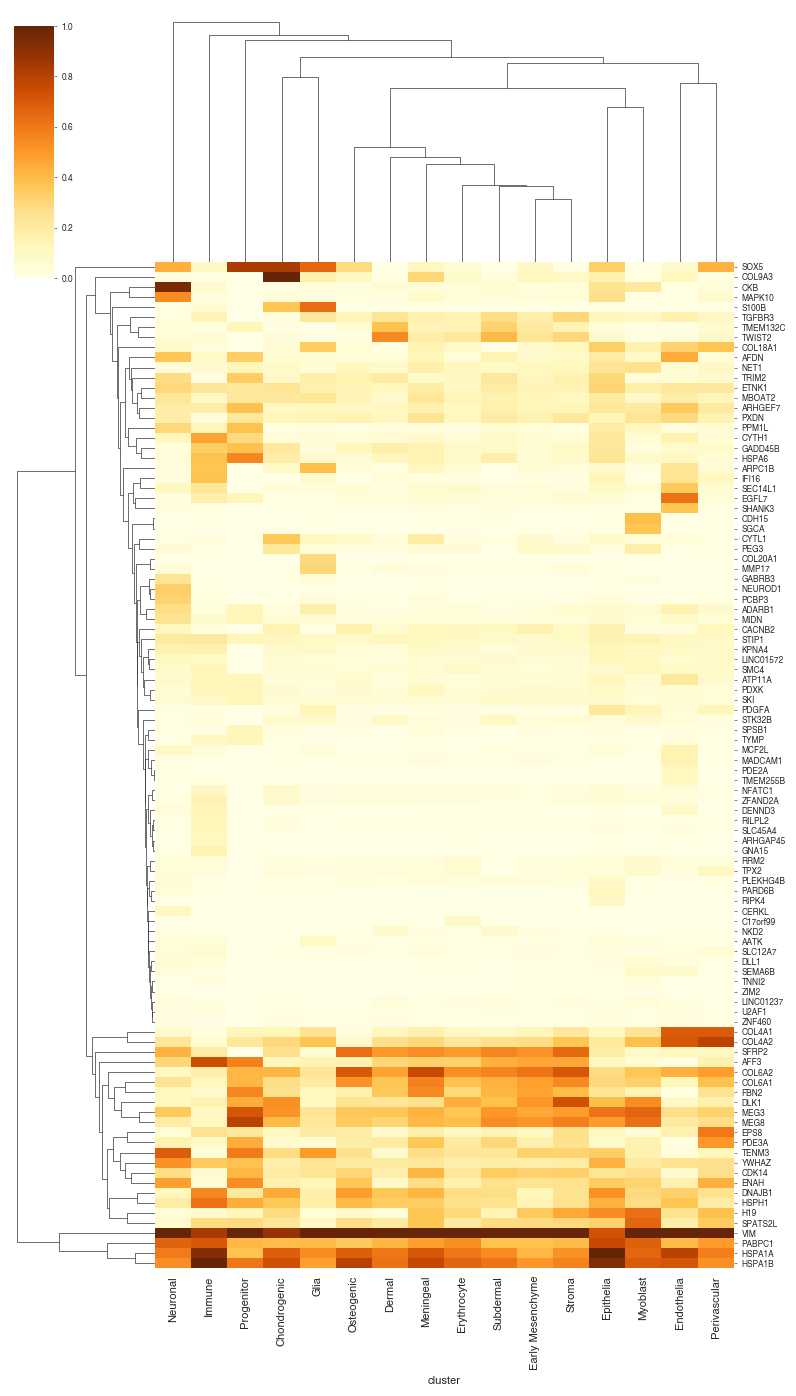

In [ ]:
## same, but for 9th week stage
# filter to age 9
adata_age9 = adata_sc[adata_sc.obs['Age'] == '9'].copy()

# compute mean expression per cluster for age 9
mean_expr = pd.DataFrame(
    adata_age9[:, target_genes].X.toarray() if hasattr(adata_age9[:, target_genes].X, 'toarray')
    else np.array(adata_age9[:, target_genes].X),
    columns=target_genes
)
mean_expr['cluster'] = adata_age9.obs['ann_clusters'].values
mean_per_cluster = mean_expr.groupby('cluster')[target_genes].mean()

# clustermap
sns.clustermap(
    mean_per_cluster.T,
    cmap='YlOrBr',
    figsize=(8, 14),
    standard_scale=1,
    yticklabels=True,
    xticklabels=True,
)
plt.savefig('../plots/clustermap_genes_age9.pdf', bbox_inches='tight', transparent=True)